# CTransPath Fine-tuning — Three Image Sets (Kaggle)

Fine-tunes CTransPath on each of three configurations:
1. **50px patches** — `path_50` column from `master_labels_s1.csv`
2. **100px patches** — `path_100` column from `master_labels_s1.csv`
3. **Masked 100px patches** — `path_100_masked` column from `master_labels_s2.csv`

### Kaggle setup checklist
1. **Model weights** — add the Kaggle model `nautynart/ctranspath` (path already set in config)
2. **Image dataset** — add `nautynart/tumor-images`; image paths in the CSVs already point to `/kaggle/input/datasets/nautynart/tumor-images/...` — no remapping needed
3. **CSV + norm files** — uploaded `master_labels_s1.csv`, `master_labels_s2.csv`, and `norm_stats.csv`
4. Enable **GPU** in *Settings → Accelerator*

All outputs are saved to `/kaggle/working/ctranspath_runs/`.

In [6]:
# ── Imports ─────────────────────────────────────────────────────────────────
import os, sys, warnings, random, json, time
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import timm
from timm.models.layers import to_2tuple, trunc_normal_

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
print(f'torch {torch.__version__}  |  timm {timm.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')

torch 2.10.0+cu128  |  timm 1.0.25
CUDA available: True


In [7]:
# ── Configuration ───────────────────────────────────────────────────────────
import os, random
import numpy as np
import pandas as pd
import torch
from pathlib import Path

# ── Kaggle paths ─────────────────────────────────────────────────────────────
WEIGHTS    = Path('/kaggle/input/models/nautynart/ctranspath/transformers/default/1/ctranspath.pth')
S1_CSV     = Path('/kaggle/input/datasets/nautynart/preprocessing-results/master_labels_s1.csv')
S2_CSV     = Path('/kaggle/input/datasets/nautynart/preprocessing-results/master_labels_s2.csv')
NORM_STATS = Path('//kaggle/input/datasets/nautynart/preprocessing-results/norm_stats.csv')
OUT_DIR    = Path('/kaggle/working/ctranspath_runs')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Load dataset-specific normalisation stats ────────────────────────────────
_ns          = pd.read_csv(NORM_STATS)
DATASET_MEAN = tuple(_ns['mean'].tolist())
DATASET_STD  = tuple(_ns['std'].tolist())
print(f'Normalisation  mean : {tuple(f"{v:.4f}" for v in DATASET_MEAN)}')
print(f'Normalisation  std  : {tuple(f"{v:.4f}" for v in DATASET_STD)}')

# ── Three experiment definitions: (name, csv_path, image_col) ───────────────
EXPERIMENTS = [
    ('50px',         S1_CSV, 'path_50'),
    ('100px',        S1_CSV, 'path_100'),
    ('100px_masked', S2_CSV, 'path_100_masked'),
]

# ── Hyperparameters ─────────────────────────────────────────────────────────
IMG_SIZE         = 224
BATCH_SIZE       = 32
NUM_EPOCHS       = 20          # more epochs; early stopping will cut them short
LR               = 1e-4
WEIGHT_DECAY     = 1e-4        # ↑ from 1e-5 — stronger L2 regularisation
FREEZE_EPOCHS    = 3
PATIENCE         = 5           # early stopping: stop after 5 epochs of no val improvement
DROPOUT          = 0.5         # ↑ from 0.3 — higher classifier dropout
LABEL_SMOOTHING  = 0.1         # smooths one-hot targets to reduce overconfidence
NUM_WORKERS      = 2
SEED             = 42
DEVICE           = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CLASS_NAMES   = {0: 'Tumor', 1: 'DCIS_1', 2: 'DCIS_2'}
NUM_CLASSES   = len(CLASS_NAMES)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f'Device          : {DEVICE}')
print(f'Weights         : {WEIGHTS}  (exists={WEIGHTS.exists()})')
print(f'S1 CSV          : {S1_CSV}   (exists={S1_CSV.exists()})')
print(f'S2 CSV          : {S2_CSV}   (exists={S2_CSV.exists()})')
print(f'Out dir         : {OUT_DIR}')
print(f'Weight decay    : {WEIGHT_DECAY}')
print(f'Dropout         : {DROPOUT}')
print(f'Label smoothing : {LABEL_SMOOTHING}')
print(f'Early stop (patience): {PATIENCE}')


Normalisation  mean : ('0.7245', '0.6050', '0.8289')
Normalisation  std  : ('0.1451', '0.1483', '0.0758')
Device          : cuda
Weights         : /kaggle/input/models/nautynart/ctranspath/transformers/default/1/ctranspath.pth  (exists=True)
S1 CSV          : /kaggle/input/datasets/nautynart/preprocessing-results/master_labels_s1.csv   (exists=True)
S2 CSV          : /kaggle/input/datasets/nautynart/preprocessing-results/master_labels_s2.csv   (exists=True)
Out dir         : /kaggle/working/ctranspath_runs
Weight decay    : 0.0001
Dropout         : 0.5
Label smoothing : 0.1
Early stop (patience): 5


## 1. Load CTransPath

In [8]:
# ── CTransPath model definition (from official repo) ────────────────────────
# Reimplemented inline — no need to clone the TransPath repo separately.

class ConvStem(nn.Module):
    """CTransPath uses a convolutional stem instead of the standard patch embed."""
    def __init__(self, img_size=224, patch_size=4, in_chans=3,
                 embed_dim=768, norm_layer=None, flatten=True):
        super().__init__()
        assert patch_size == 4
        assert embed_dim % 8 == 0
        img_size   = to_2tuple(img_size)
        patch_size = to_2tuple(patch_size)
        self.img_size    = img_size
        self.patch_size  = patch_size
        self.grid_size   = (img_size[0] // patch_size[0],
                            img_size[1] // patch_size[1])
        self.num_patches = self.grid_size[0] * self.grid_size[1]
        self.flatten     = flatten

        stem = []
        input_dim, output_dim = 3, embed_dim // 8
        for _ in range(2):
            stem += [
                nn.Conv2d(input_dim, output_dim,
                          kernel_size=3, stride=2, padding=1, bias=False),
                nn.BatchNorm2d(output_dim),
                nn.ReLU(inplace=True),
            ]
            input_dim  = output_dim
            output_dim = output_dim * 2
        stem.append(nn.Conv2d(input_dim, embed_dim, kernel_size=1))
        self.proj = nn.Sequential(*stem)
        self.norm = norm_layer(embed_dim) if norm_layer else nn.Identity()

    def forward(self, x):
        x = self.proj(x)                # (B, C, H, W)
        x = x.permute(0, 2, 3, 1)      # (B, H, W, C)  ← new timm expects 4-D
        x = self.norm(x)
        return x


def ctranspath():
    model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=False)
    model.head = nn.Identity()

    # Replace PatchEmbed with ConvStem.
    # Use nn.LayerNorm to match the saved weights which contain
    # "patch_embed.norm.weight" / "patch_embed.norm.bias".
    embed_dim = model.patch_embed.proj.out_channels  # 96 for swin_tiny
    model.patch_embed = ConvStem(
        img_size=224, patch_size=4, in_chans=3,
        embed_dim=embed_dim, norm_layer=nn.LayerNorm, flatten=True
    )
    return model


def load_ctranspath(weights_path: Path) -> nn.Module:
    model = ctranspath()
    td    = torch.load(weights_path, map_location='cpu')
    state = td.get('model', td)

    # ── Fix timm version mismatch ────────────────────────────────────────────
    # The checkpoint was saved with an older timm where PatchMerging for the
    # stage-N→(N+1) transition was stored inside layers.N.  Current timm
    # stores it at the start of layers.(N+1) instead.  Remap accordingly.
    DOWNSAMPLE_REMAP = {
        'layers.0.downsample.': 'layers.1.downsample.',
        'layers.1.downsample.': 'layers.2.downsample.',
        'layers.2.downsample.': 'layers.3.downsample.',
    }
    # These are computed buffers (not learnable); they differ between timm
    # versions and should be re-created by the model rather than loaded.
    SKIP_SUBSTRINGS = ('relative_position_index', 'attn_mask')

    remapped, skipped = {}, []
    for k, v in state.items():
        if any(s in k for s in SKIP_SUBSTRINGS):
            skipped.append(k)
            continue
        for old_prefix, new_prefix in DOWNSAMPLE_REMAP.items():
            if k.startswith(old_prefix):
                k = new_prefix + k[len(old_prefix):]
                break
        remapped[k] = v

    if skipped:
        print(f'  Skipped {len(skipped)} computed-buffer keys '
              f'(relative_position_index / attn_mask)')

    missing    = set(model.state_dict()) - set(remapped)
    unexpected = set(remapped) - set(model.state_dict())
    if missing:
        print(f'  WARNING — keys missing after remap: {missing}')
    if unexpected:
        print(f'  WARNING — unexpected keys after remap: {unexpected}')

    model.load_state_dict(remapped, strict=True)
    print(f'Loaded CTransPath weights from {weights_path}')
    return model


backbone = load_ctranspath(WEIGHTS)
# Confirm output dimension with a dummy forward pass
with torch.no_grad():
    _dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)
    _feat  = backbone(_dummy)
    FEAT_DIM = _feat.shape[-1]
print(f'Backbone feature dim: {FEAT_DIM}')

  Skipped 17 computed-buffer keys (relative_position_index / attn_mask)
Loaded CTransPath weights from /kaggle/input/models/nautynart/ctranspath/transformers/default/1/ctranspath.pth
Backbone feature dim: 768


## 2. Dataset & DataLoaders

In [9]:
# ── Transforms ──────────────────────────────────────────────────────────────
from torchvision import transforms
from torchvision.transforms import RandomApply, GaussianBlur
from torch.utils.data import Dataset, DataLoader
from PIL import Image

# Use dataset-specific stats loaded from norm_stats.csv (set in config cell)
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(degrees=90),               # cell patches have no orientation
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.2, hue=0.1),     # stronger stain variation
    RandomApply([GaussianBlur(kernel_size=3)], p=0.25),  # simulates slight blur/focus variation
    transforms.ToTensor(),
    transforms.Normalize(mean=DATASET_MEAN, std=DATASET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=DATASET_MEAN, std=DATASET_STD),
])


# ── Dataset ─────────────────────────────────────────────────────────────────
class TumourPatchDataset(Dataset):
    """Loads single-resolution tumour patches from a master-labels CSV."""

    def __init__(self, csv_path: Path, img_col: str, split: str,
                 transform=None):
        df = pd.read_csv(csv_path)
        self.df        = df[df['split'] == split].reset_index(drop=True).copy()
        self.img_col   = img_col
        self.transform = transform

        missing = (~self.df[img_col].apply(os.path.exists)).sum()
        if missing:
            print(f'  WARNING [{split}|{img_col}]: {missing}/{len(self.df)} missing files')
        else:
            print(f'  [{img_col}] {split:5s}: {len(self.df):,} samples — all paths OK')

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row[self.img_col]).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, int(row['label'])


def make_loaders(csv_path: Path, img_col: str, batch_size: int = BATCH_SIZE):
    """Returns {'train', 'val', 'test'} DataLoaders for one experiment."""
    loaders = {}
    for split, tfm in [('train', train_transform),
                        ('val',   eval_transform),
                        ('test',  eval_transform)]:
        ds = TumourPatchDataset(csv_path, img_col, split, tfm)
        loaders[split] = DataLoader(
            ds, batch_size=batch_size,
            shuffle=(split == 'train'),
            num_workers=NUM_WORKERS,
            pin_memory=(DEVICE.type == 'cuda')
        )
    return loaders


# Sanity-check one experiment
print('=== Checking 50px split sizes ===')
_ = make_loaders(S1_CSV, 'path_50')

=== Checking 50px split sizes ===
  [path_50] train: 21,000 samples — all paths OK
  [path_50] val  : 4,500 samples — all paths OK
  [path_50] test : 2,832 samples — all paths OK


## 3. Model — CTransPath Classifier

In [13]:
class CTranspathClassifier(nn.Module):
    def __init__(self, backbone: nn.Module, num_classes: int,
                 feat_dim: int = 768, dropout: float = 0.5):
        super().__init__()
        self.backbone = backbone
        self.classifier = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Linear(feat_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),          # dropout after first projection
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(dropout * 0.6),    # lighter dropout before final layer
            nn.Linear(128, num_classes),
        )

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True

    def forward(self, x):
        features = self.backbone(x)
        # Newer timm may return (B, H, W, C) instead of (B, C) when
        # head=Identity() skips global pooling — flatten spatial dims.
        if features.dim() == 4:          # (B, H, W, C)
            features = features.mean(dim=(1, 2))   # → (B, C)
        elif features.dim() == 3:        # (B, N, C) — old timm sequence output
            features = features.mean(dim=1)        # → (B, C)
        return self.classifier(features)


def build_model(backbone_weights: Path) -> CTranspathClassifier:
    """Fresh model for each experiment (re-loads pretrained weights)."""
    bb    = load_ctranspath(backbone_weights)
    model = CTranspathClassifier(
        bb, num_classes=NUM_CLASSES, feat_dim=FEAT_DIM, dropout=DROPOUT
    )
    return model.to(DEVICE)


print('Model architecture verified.')

Model architecture verified.


## 4. Training & Evaluation Utilities

In [14]:
def train_epoch(model, loader, optimizer, criterion, scaler=None):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for imgs, labels in tqdm(loader, leave=False, desc='train'):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        if scaler is not None:
            with torch.cuda.amp.autocast():
                logits = model(imgs)
                loss   = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(imgs)
            loss   = criterion(logits, labels)
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * len(labels)
        correct    += (logits.argmax(1) == labels).sum().item()
        n          += len(labels)
    return total_loss / n, correct / n


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    for imgs, labels in tqdm(loader, leave=False, desc='eval '):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits       = model(imgs)
        loss         = criterion(logits, labels)
        probs        = torch.softmax(logits, dim=1)
        preds        = logits.argmax(1)
        total_loss  += loss.item() * len(labels)
        correct     += (preds == labels).sum().item()
        n           += len(labels)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
        all_probs.append(probs.cpu().numpy())
    all_probs = np.vstack(all_probs)
    return total_loss / n, correct / n, all_preds, all_labels, all_probs


def plot_training_curves(history: dict, exp_name: str, save_path: Path):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'Training curves — {exp_name}', fontweight='bold')

    axes[0].plot(epochs, history['train_loss'], label='Train')
    axes[0].plot(epochs, history['val_loss'],   label='Val')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    axes[1].plot(epochs, history['train_acc'], label='Train')
    axes[1].plot(epochs, history['val_acc'],   label='Val')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_confusion_matrix(preds, labels, class_names: dict,
                           exp_name: str, save_path: Path):
    names = [class_names[i] for i in sorted(class_names)]
    cm = confusion_matrix(labels, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'Confusion matrix — {exp_name}', fontweight='bold')

    for ax, mat, fmt, title in zip(
        axes,
        [cm, cm_norm],
        ['d', '.2f'],
        ['Counts', 'Normalised']
    ):
        sns.heatmap(mat, annot=True, fmt=fmt, cmap='Blues',
                    xticklabels=names, yticklabels=names, ax=ax)
        ax.set_title(title)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


print('Utilities ready.')

Utilities ready.


## 5. Run All Three Experiments


  EXPERIMENT: 50px
  CSV:        master_labels_s1.csv
  Image col:  path_50
  [path_50] train: 21,000 samples — all paths OK
  [path_50] val  : 4,500 samples — all paths OK
  [path_50] test : 2,832 samples — all paths OK
  Skipped 17 computed-buffer keys (relative_position_index / attn_mask)
Loaded CTransPath weights from /kaggle/input/models/nautynart/ctranspath/transformers/default/1/ctranspath.pth
  Backbone FROZEN for first 3 epochs.


train:   0%|          | 0/657 [00:00<?, ?it/s]

eval :   0%|          | 0/141 [00:00<?, ?it/s]

  Epoch 01/20  tr_loss=1.0406  tr_acc=0.4677  vl_loss=0.9318  vl_acc=0.6131  (208.2s)
    ✓ New best val_acc=0.6131 — saved checkpoint


train:   0%|          | 0/657 [00:00<?, ?it/s]

...

train:   0%|          | 0/657 [00:00<?, ?it/s]

eval :   0%|          | 0/141 [00:00<?, ?it/s]

  Epoch 20/20  tr_loss=0.4775  tr_acc=0.9112  vl_loss=0.4656  vl_acc=0.9169  (172.1s)
    No improvement (1/5)


eval :   0%|          | 0/89 [00:00<?, ?it/s]


  Test accuracy: 0.9386
              precision    recall  f1-score   support

       Tumor       0.97      0.95      0.96      1203
      DCIS_1       0.91      0.98      0.94       892
      DCIS_2       0.92      0.86      0.89       737

    accuracy                           0.94      2832
   macro avg       0.93      0.93      0.93      2832
weighted avg       0.94      0.94      0.94      2832



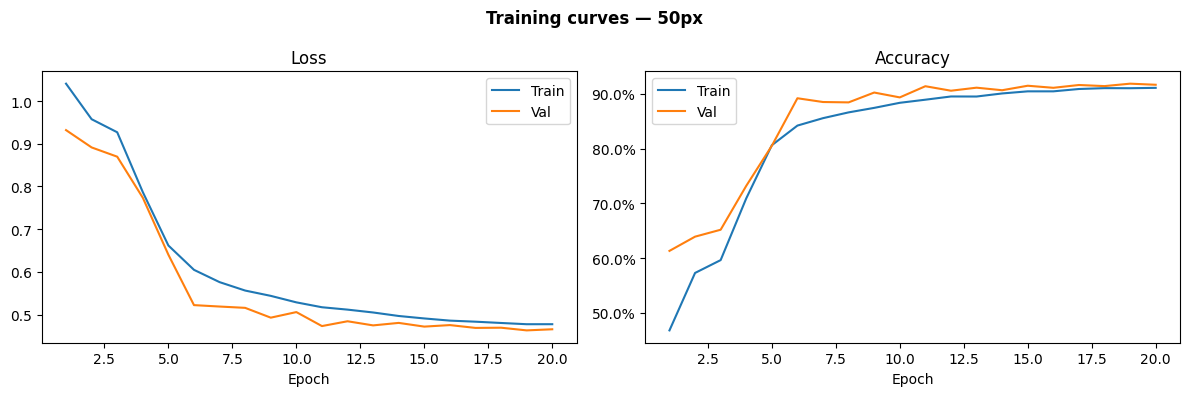

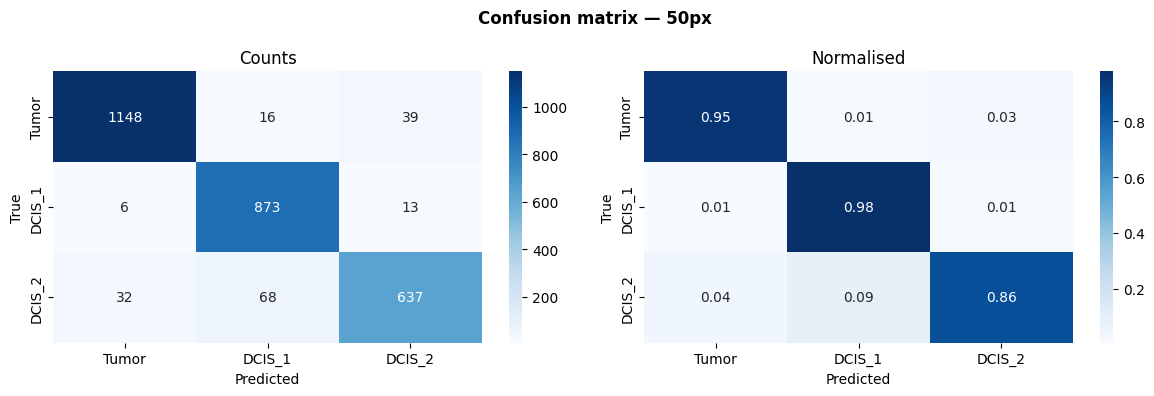


  EXPERIMENT: 100px
  CSV:        master_labels_s1.csv
  Image col:  path_100
  [path_100] train: 21,000 samples — all paths OK
  [path_100] val  : 4,500 samples — all paths OK
  [path_100] test : 2,832 samples — all paths OK
  Skipped 17 computed-buffer keys (relative_position_index / attn_mask)
Loaded CTransPath weights from /kaggle/input/models/nautynart/ctranspath/transformers/default/1/ctranspath.pth
  Backbone FROZEN for first 3 epochs.


train:   0%|          | 0/657 [00:00<?, ?it/s]

eval :   0%|          | 0/141 [00:00<?, ?it/s]

  Epoch 01/20  tr_loss=0.9545  tr_acc=0.5662  vl_loss=0.7371  vl_acc=0.7553  (245.4s)
    ✓ New best val_acc=0.7553 — saved checkpoint


train:   0%|          | 0/657 [00:00<?, ?it/s]

...

train:   0%|          | 0/657 [00:00<?, ?it/s]

eval :   0%|          | 0/141 [00:00<?, ?it/s]

  Epoch 20/20  tr_loss=0.4371  tr_acc=0.9354  vl_loss=0.4238  vl_acc=0.9433  (181.2s)
    No improvement (4/5)


eval :   0%|          | 0/89 [00:00<?, ?it/s]


  Test accuracy: 0.9530
              precision    recall  f1-score   support

       Tumor       0.98      0.96      0.97      1203
      DCIS_1       0.93      0.98      0.96       892
      DCIS_2       0.93      0.91      0.92       737

    accuracy                           0.95      2832
   macro avg       0.95      0.95      0.95      2832
weighted avg       0.95      0.95      0.95      2832



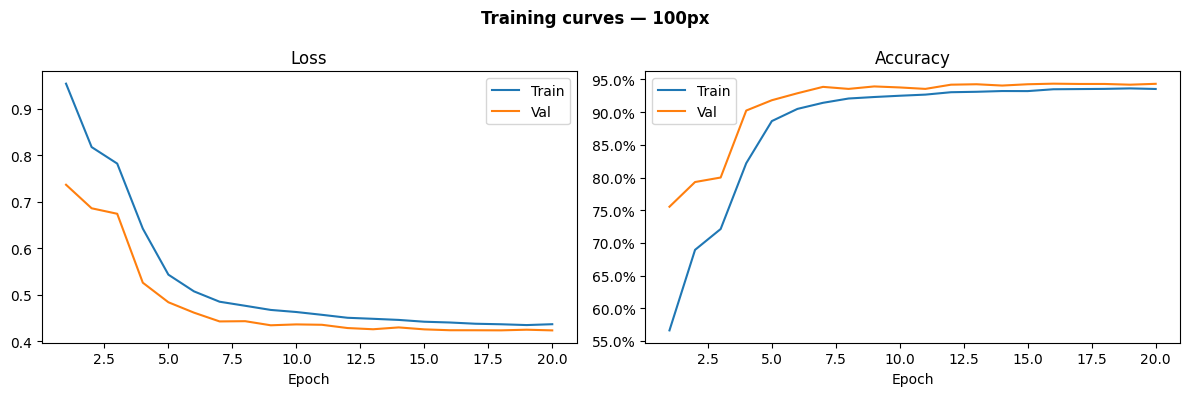

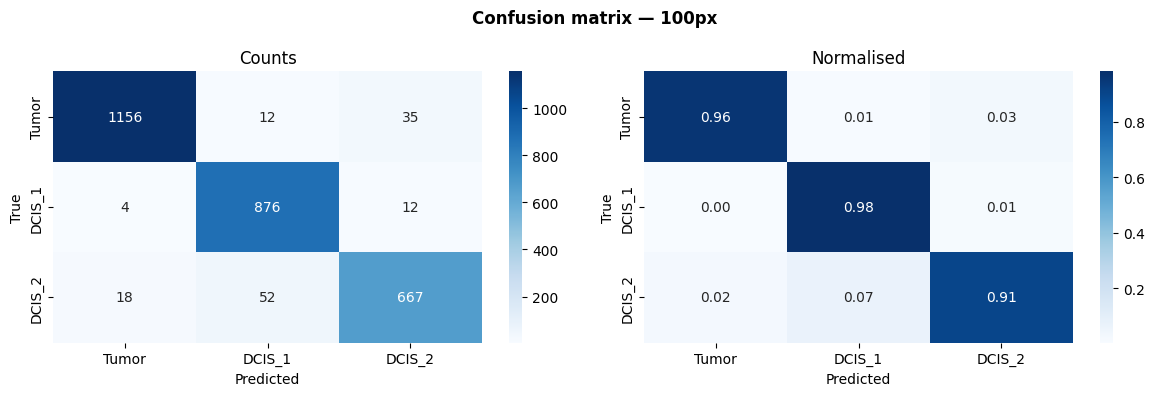


  EXPERIMENT: 100px_masked
  CSV:        master_labels_s2.csv
  Image col:  path_100_masked
  [path_100_masked] train: 21,000 samples — all paths OK
  [path_100_masked] val  : 4,500 samples — all paths OK
  [path_100_masked] test : 4,500 samples — all paths OK
  Skipped 17 computed-buffer keys (relative_position_index / attn_mask)
Loaded CTransPath weights from /kaggle/input/models/nautynart/ctranspath/transformers/default/1/ctranspath.pth
  Backbone FROZEN for first 3 epochs.


train:   0%|          | 0/657 [00:00<?, ?it/s]

eval :   0%|          | 0/141 [00:00<?, ?it/s]

  Epoch 01/20  tr_loss=1.0687  tr_acc=0.4271  vl_loss=1.0051  vl_acc=0.5413  (207.1s)
    ✓ New best val_acc=0.5413 — saved checkpoint


train:   0%|          | 0/657 [00:00<?, ?it/s]

...

train:   0%|          | 0/657 [00:00<?, ?it/s]

eval :   0%|          | 0/141 [00:00<?, ?it/s]

  Epoch 20/20  tr_loss=0.5232  tr_acc=0.8854  vl_loss=0.5017  vl_acc=0.8980  (172.8s)
    ✓ New best val_acc=0.8980 — saved checkpoint


eval :   0%|          | 0/141 [00:00<?, ?it/s]


  Test accuracy: 0.8989
              precision    recall  f1-score   support

       Tumor       0.94      0.90      0.92      1500
      DCIS_1       0.87      0.96      0.91      1500
      DCIS_2       0.89      0.84      0.87      1500

    accuracy                           0.90      4500
   macro avg       0.90      0.90      0.90      4500
weighted avg       0.90      0.90      0.90      4500



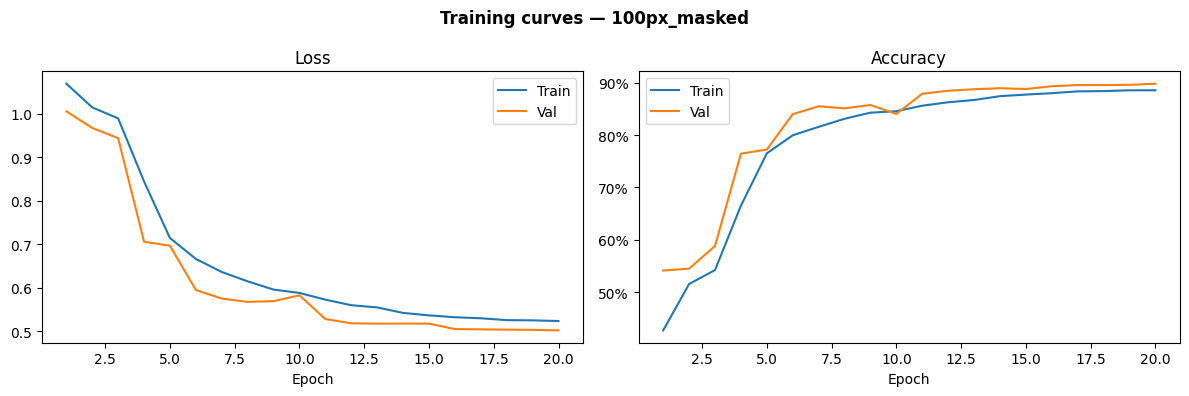

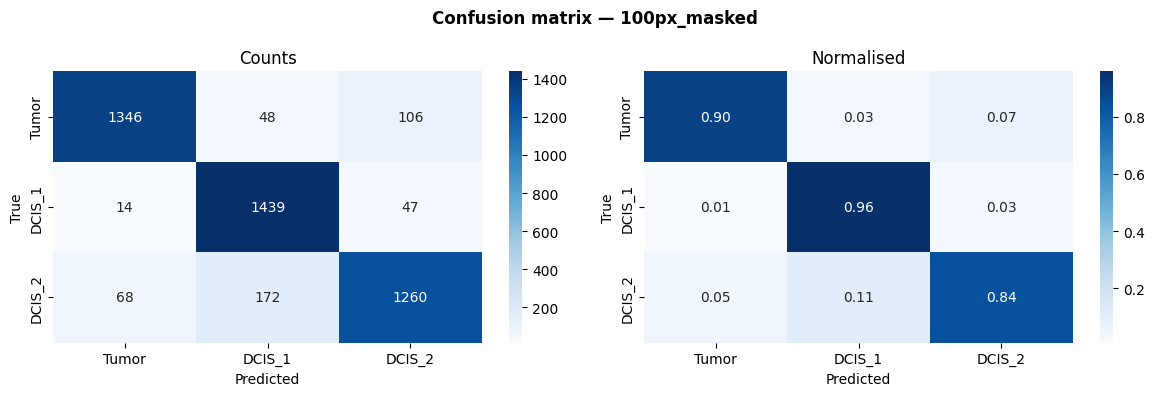


All experiments complete.


In [15]:
all_results = {}   # stores final test metrics per experiment

for exp_name, csv_path, img_col in EXPERIMENTS:
    print(f'\n{"="*60}')
    print(f'  EXPERIMENT: {exp_name}')
    print(f'  CSV:        {csv_path.name}')
    print(f'  Image col:  {img_col}')
    print(f'{"="*60}')

    exp_dir = OUT_DIR / exp_name
    exp_dir.mkdir(parents=True, exist_ok=True)

    # ── DataLoaders ────────────────────────────────────────────────────────
    loaders = make_loaders(csv_path, img_col)

    # ── Model ──────────────────────────────────────────────────────────────
    model = build_model(WEIGHTS)

    # Compute class weights from training set for imbalanced classes
    train_df     = pd.read_csv(csv_path)
    train_df     = train_df[train_df['split'] == 'train']
    class_counts = train_df['label'].value_counts().sort_index().values
    class_weights = torch.tensor(
        1.0 / class_counts / (1.0 / class_counts).sum(),
        dtype=torch.float32
    ).to(DEVICE)

    # Label smoothing reduces overconfident predictions
    criterion = nn.CrossEntropyLoss(
        weight=class_weights, label_smoothing=LABEL_SMOOTHING
    )

    # Head-only optimizer for frozen phase
    optimizer = torch.optim.AdamW(
        model.classifier.parameters(), lr=LR, weight_decay=WEIGHT_DECAY
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=FREEZE_EPOCHS
    )
    scaler = torch.cuda.amp.GradScaler() if DEVICE.type == 'cuda' else None

    # Phase 1: freeze backbone, warm up the head
    model.freeze_backbone()
    print(f'  Backbone FROZEN for first {FREEZE_EPOCHS} epochs.')

    history          = dict(train_loss=[], val_loss=[], train_acc=[], val_acc=[])
    best_val_acc     = 0.0
    best_ckpt        = exp_dir / 'best_model.pth'
    epochs_no_improve = 0

    for epoch in range(1, NUM_EPOCHS + 1):
        # ── Unfreeze backbone + reset optimizer with differential LR ──────
        if epoch == FREEZE_EPOCHS + 1:
            model.unfreeze_backbone()
            remaining = NUM_EPOCHS - FREEZE_EPOCHS
            optimizer = torch.optim.AdamW([
                {'params': model.classifier.parameters(), 'lr': LR},
                {'params': model.backbone.parameters(),   'lr': LR * 0.1},
            ], weight_decay=WEIGHT_DECAY)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=remaining
            )
            epochs_no_improve = 0   # reset patience counter after unfreeze
            print(f'  Backbone UNFROZEN at epoch {epoch}  '
                  f'(backbone LR={LR * 0.1:.2e}, head LR={LR:.2e})')

        t0 = time.time()
        tr_loss, tr_acc = train_epoch(model, loaders['train'], optimizer,
                                       criterion, scaler)
        vl_loss, vl_acc, _, _, _ = eval_epoch(model, loaders['val'], criterion)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        elapsed = time.time() - t0
        print(f'  Epoch {epoch:02d}/{NUM_EPOCHS}  '
              f'tr_loss={tr_loss:.4f}  tr_acc={tr_acc:.4f}  '
              f'vl_loss={vl_loss:.4f}  vl_acc={vl_acc:.4f}  '
              f'({elapsed:.1f}s)')

        if vl_acc > best_val_acc:
            best_val_acc      = vl_acc
            epochs_no_improve = 0
            torch.save(model.state_dict(), best_ckpt)
            print(f'    ✓ New best val_acc={best_val_acc:.4f} — saved checkpoint')
        else:
            epochs_no_improve += 1
            print(f'    No improvement ({epochs_no_improve}/{PATIENCE})')
            # Only apply early stopping after backbone is unfrozen
            if epochs_no_improve >= PATIENCE and epoch > FREEZE_EPOCHS:
                print(f'  ✗ Early stopping at epoch {epoch}.')
                break

    # Save training history
    pd.DataFrame(history).to_csv(exp_dir / 'history.csv', index=False)

    # ── Evaluate best model on test set ───────────────────────────────────
    model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))
    _, test_acc, test_preds, test_labels, test_probs = eval_epoch(
        model, loaders['test'], criterion
    )

    report = classification_report(
        test_labels, test_preds,
        target_names=[CLASS_NAMES[i] for i in range(NUM_CLASSES)],
        output_dict=True
    )
    print(f'\n  Test accuracy: {test_acc:.4f}')
    print(classification_report(
        test_labels, test_preds,
        target_names=[CLASS_NAMES[i] for i in range(NUM_CLASSES)]
    ))

    # Save report
    pd.DataFrame(report).T.to_csv(exp_dir / 'test_report.csv')

    # ── Plots ──────────────────────────────────────────────────────────────
    plot_training_curves(history, exp_name, exp_dir / 'training_curves.png')
    plot_confusion_matrix(test_preds, test_labels, CLASS_NAMES,
                           exp_name, exp_dir / 'confusion_matrix.png')

    all_results[exp_name] = {
        'test_acc':      test_acc,
        'best_val_acc':  best_val_acc,
        'report':        report,
        'history':       history,
        'test_preds':    test_preds,
        'test_labels':   test_labels,
        'test_probs':    test_probs,
    }

print('\nAll experiments complete.')


## 6. Compare Results Across Experiments

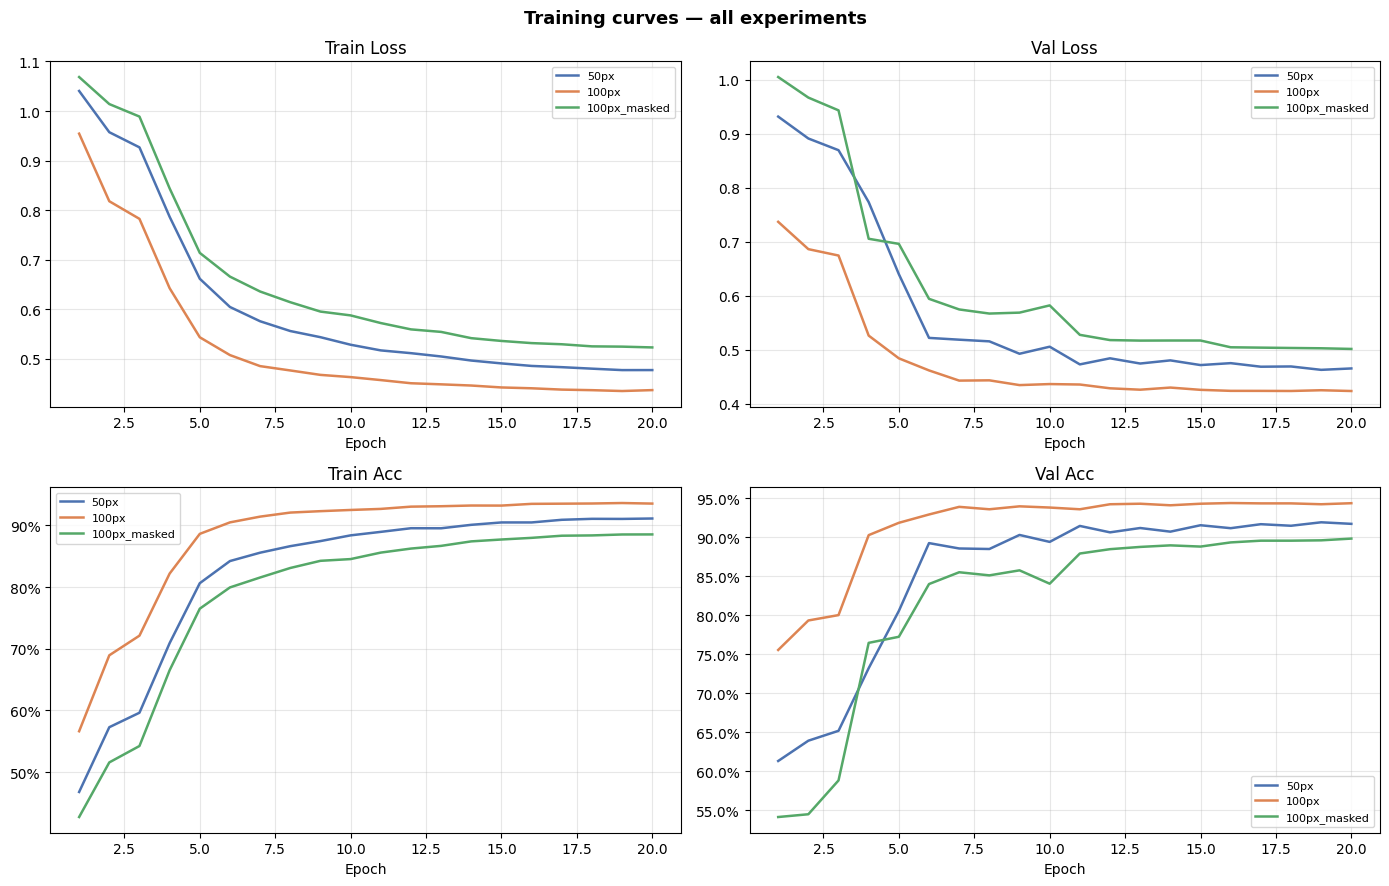

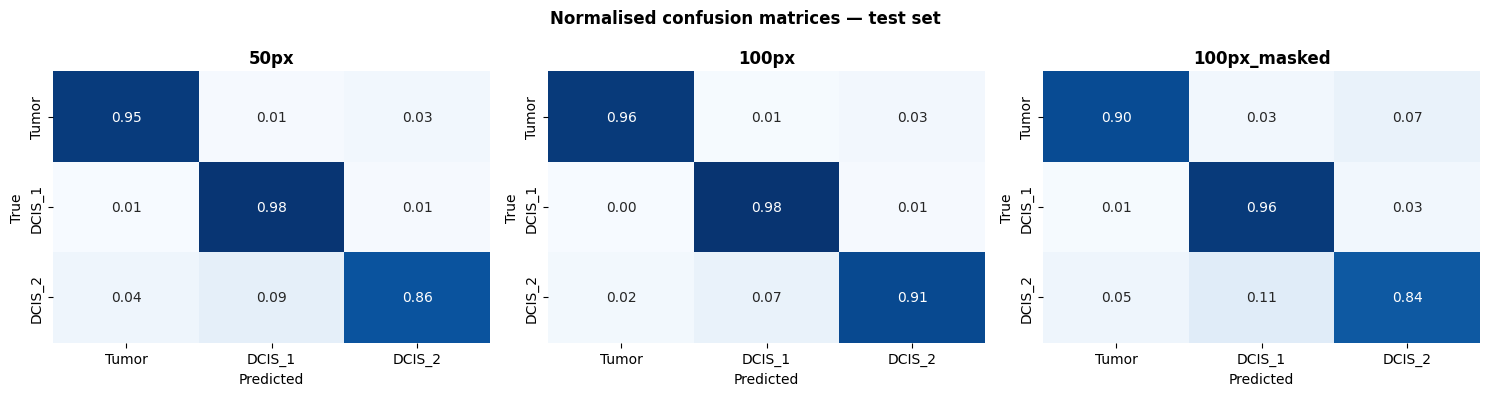

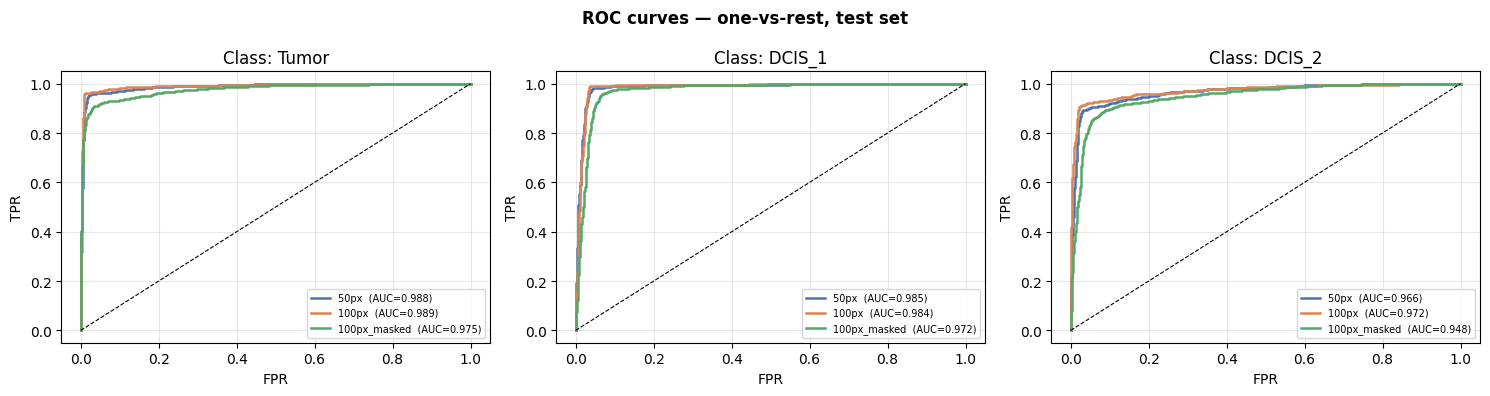

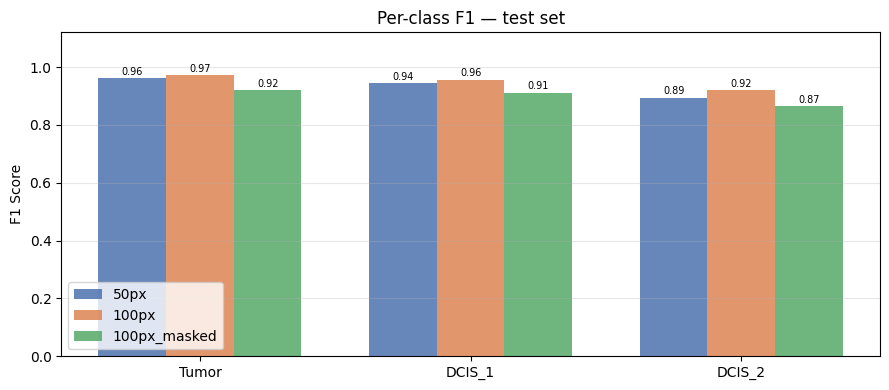

  Experiment Test Acc Macro F1 Weighted F1    MCC Cohen's κ ROC-AUC (macro OvR)
        50px   0.9386   0.9329      0.9382 0.9064    0.9058              0.9793
       100px   0.9530   0.9489      0.9530 0.9284    0.9281              0.9817
100px_masked   0.8989   0.8985      0.8985 0.8495    0.8483              0.9649

Full summary saved → /kaggle/working/ctranspath_runs/comparison_summary.csv


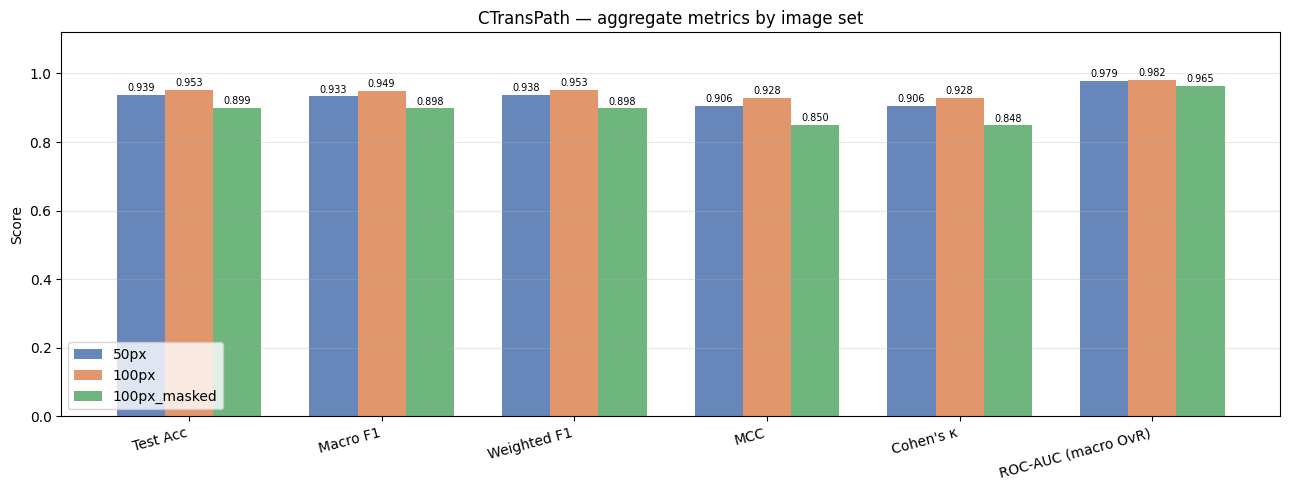

In [16]:
from sklearn.metrics import (
    matthews_corrcoef, cohen_kappa_score,
    roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

EXP_NAMES  = list(all_results.keys())
PALETTE    = ['#4C72B0', '#DD8452', '#55A868']
CLASS_LIST = [CLASS_NAMES[i] for i in range(NUM_CLASSES)]

# ══════════════════════════════════════════════════════════════════════════════
# 1.  Overlaid training curves  (loss + accuracy, one subplot per metric)
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Training curves — all experiments', fontweight='bold', fontsize=13)

titles = [('Train Loss', 'train_loss'), ('Val Loss',  'val_loss'),
          ('Train Acc',  'train_acc'),  ('Val Acc',   'val_acc')]

for ax, (title, key) in zip(axes.flat, titles):
    for col, exp in zip(PALETTE, EXP_NAMES):
        vals   = all_results[exp]['history'][key]
        epochs = range(1, len(vals) + 1)
        ax.plot(epochs, vals, label=exp, color=col, linewidth=1.8)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    if 'Acc' in title:
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'compare_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# 2.  Side-by-side normalised confusion matrices
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, len(EXP_NAMES), figsize=(5 * len(EXP_NAMES), 4))
fig.suptitle('Normalised confusion matrices — test set', fontweight='bold', fontsize=12)

for ax, exp in zip(axes, EXP_NAMES):
    res  = all_results[exp]
    cm   = confusion_matrix(res['test_labels'], res['test_preds'])
    cmn  = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cmn, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASS_LIST, yticklabels=CLASS_LIST,
                ax=ax, vmin=0, vmax=1, cbar=False)
    ax.set_title(exp, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.savefig(OUT_DIR / 'compare_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# 3.  ROC curves  (one-vs-rest per class, overlaid across experiments)
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(5 * NUM_CLASSES, 4))
fig.suptitle('ROC curves — one-vs-rest, test set', fontweight='bold', fontsize=12)

for cls_idx, (ax, cls_name) in enumerate(zip(axes, CLASS_LIST)):
    for col, exp in zip(PALETTE, EXP_NAMES):
        res   = all_results[exp]
        y_bin = (np.array(res['test_labels']) == cls_idx).astype(int)
        y_scr = res['test_probs'][:, cls_idx]
        fpr, tpr, _ = roc_curve(y_bin, y_scr)
        roc_auc     = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'{exp}  (AUC={roc_auc:.3f})',
                color=col, linewidth=1.8)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
    ax.set_title(f'Class: {cls_name}')
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'compare_roc.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# 4.  Per-class F1 grouped bar chart
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 4))
x     = np.arange(NUM_CLASSES)
width = 0.25

for i, (exp, col) in enumerate(zip(EXP_NAMES, PALETTE)):
    r    = all_results[exp]['report']
    f1s  = [r[cn]['f1-score'] for cn in CLASS_LIST]
    bars = ax.bar(x + i * width, f1s, width, label=exp, color=col, alpha=0.85)
    for bar, v in zip(bars, f1s):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{v:.2f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x + width)
ax.set_xticklabels(CLASS_LIST)
ax.set_ylim(0, 1.12)
ax.set_ylabel('F1 Score')
ax.set_title('Per-class F1 — test set')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'compare_per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# 5.  Summary metrics table
#     Includes: Accuracy, Macro F1, Weighted F1, MCC, Cohen's κ, macro ROC-AUC
# ══════════════════════════════════════════════════════════════════════════════
rows = []
for exp in EXP_NAMES:
    res    = all_results[exp]
    r      = res['report']
    labels = np.array(res['test_labels'])
    preds  = np.array(res['test_preds'])
    probs  = res['test_probs']

    mcc     = matthews_corrcoef(labels, preds)
    kappa   = cohen_kappa_score(labels, preds)
    roc_auc = roc_auc_score(
        label_binarize(labels, classes=list(range(NUM_CLASSES))),
        probs, multi_class='ovr', average='macro'
    )

    rows.append({
        'Experiment':   exp,
        'Test Acc':     f"{res['test_acc']:.4f}",
        'Best Val Acc': f"{res['best_val_acc']:.4f}",
        'Macro F1':     f"{r['macro avg']['f1-score']:.4f}",
        'Weighted F1':  f"{r['weighted avg']['f1-score']:.4f}",
        'MCC':          f"{mcc:.4f}",
        "Cohen's κ":    f"{kappa:.4f}",
        'ROC-AUC (macro OvR)': f"{roc_auc:.4f}",
        **{f'{cn} P':   f"{r[cn]['precision']:.4f}" for cn in CLASS_LIST},
        **{f'{cn} R':   f"{r[cn]['recall']:.4f}"    for cn in CLASS_LIST},
        **{f'{cn} F1':  f"{r[cn]['f1-score']:.4f}"  for cn in CLASS_LIST},
    })

summary_df = pd.DataFrame(rows)
summary_df.to_csv(OUT_DIR / 'comparison_summary.csv', index=False)

# Pretty-print the key columns
key_cols = ['Experiment', 'Test Acc', 'Macro F1', 'Weighted F1',
            'MCC', "Cohen's κ", 'ROC-AUC (macro OvR)']
print(summary_df[key_cols].to_string(index=False))
print(f'\nFull summary saved → {OUT_DIR}/comparison_summary.csv')

# ══════════════════════════════════════════════════════════════════════════════
# 6.  Aggregate metrics bar chart
# ══════════════════════════════════════════════════════════════════════════════
agg_metrics = ['Test Acc', 'Macro F1', 'Weighted F1',
               'MCC', "Cohen's κ", 'ROC-AUC (macro OvR)']
x     = np.arange(len(agg_metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 5))
for i, (row, col) in enumerate(zip(rows, PALETTE)):
    vals = [float(row[m]) for m in agg_metrics]
    bars = ax.bar(x + i * width, vals, width, label=row['Experiment'],
                  color=col, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x + width)
ax.set_xticklabels(agg_metrics, rotation=15, ha='right')
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('CTransPath — aggregate metrics by image set')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()